# Luu anh va video vao 2 mang rieng biet

In [50]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Gom du lieu

In [17]:
def load_images_from_folder(img_folder):
    # Các định dạng ảnh hợp lệ cần tìm kiếm
    img_extensions = ['*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG']
    
    images = [] # Mảng chứa dữ liệu pixel của ảnh
    labels = [] # Mảng chứa tên loại quả tương ứng

    # 1. Quét tất cả các mục có trong thư mục gốc (vd: thư mục Image)
    for fruit_folder in os.listdir(img_folder):
        fruit_path = os.path.join(img_folder, fruit_folder)
        
        # 2. Đảm bảo mục đang quét là thư mục (để bỏ qua các file rác/ẩn)
        if os.path.isdir(fruit_path):
            
            # 3. Lọc tìm ảnh theo từng đuôi mở rộng (png, jpg,...)
            for ext in img_extensions:
                search_pattern = os.path.join(fruit_path, ext)
                found_files = glob.glob(search_pattern) # Lấy danh sách đường dẫn ảnh
                
                # 4. Đọc từng ảnh và lưu vào mảng
                for file_path in found_files:
                    img = cv2.imread(file_path)
                    
                    # Kiểm tra xem ảnh có bị lỗi không trước khi lưu
                    if img is not None:
                        images.append(img)
                        labels.append(fruit_folder) # Dùng tên thư mục con làm nhãn (label)
                        
    return images, labels

In [18]:
dataset_folder = '../Img,Video/Image'

imges, labels = load_images_from_folder(dataset_folder)

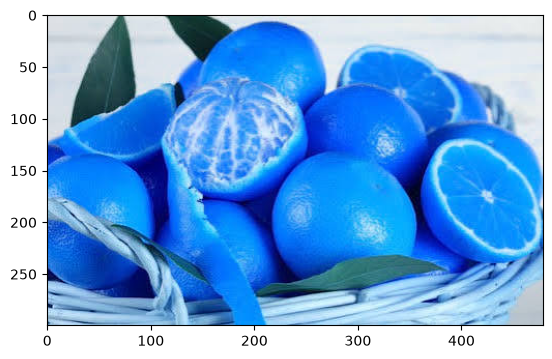

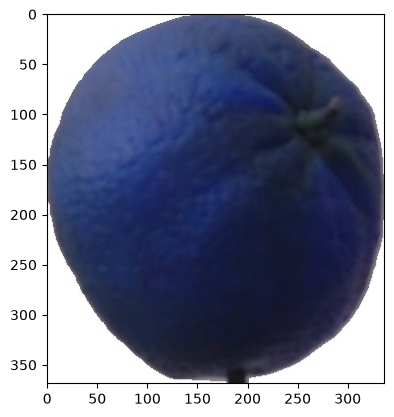

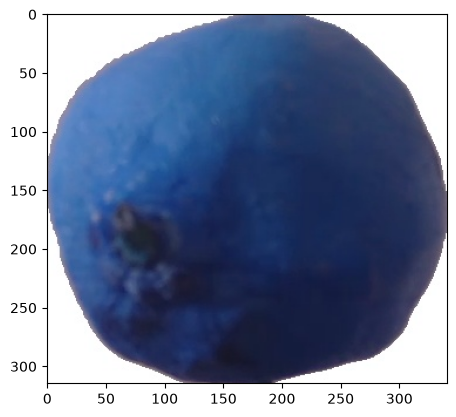

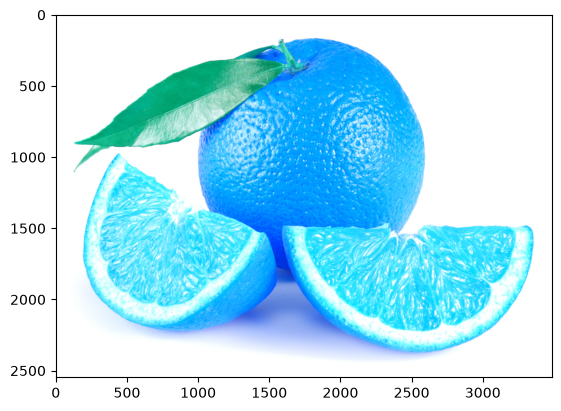

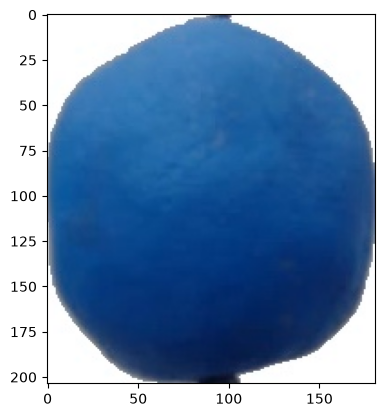

...

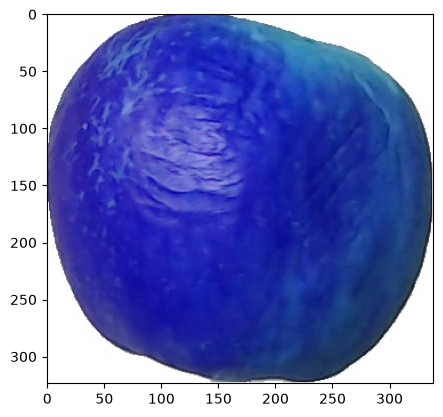

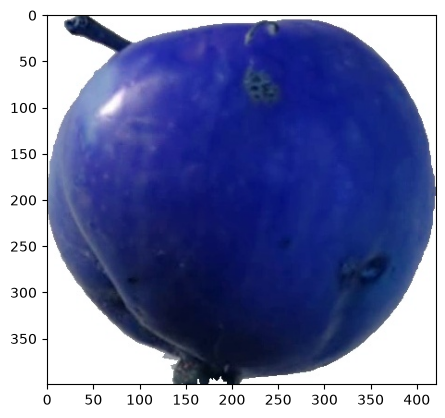

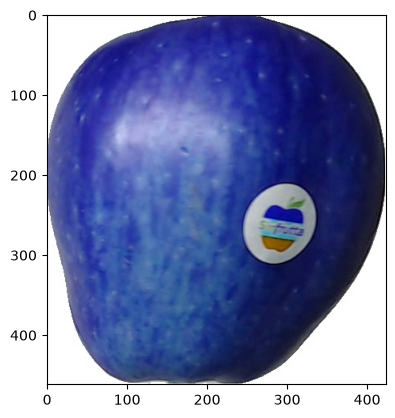

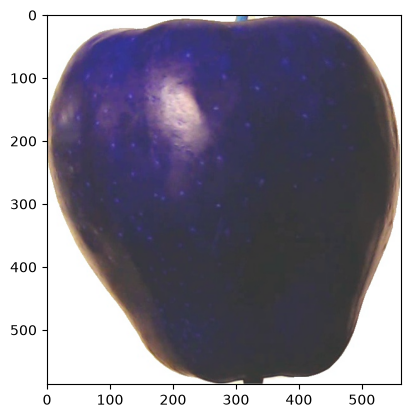

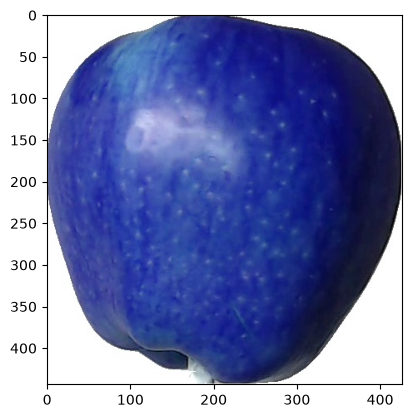

In [19]:
for i in range (len(imges)):
    plt.imshow(imges[i])
    plt.show()

# 2.BGR -> RGB

In [20]:
shape = imges[0].shape
shape, imges[0][0,0,:]

((300, 479, 3), array([221, 224, 229], dtype=uint8))

In [21]:
# chuyen sang mau rgb
imges_rgb = np.flip(imges[0], 2)
# b, g, r = cv2.split(imges[0])
# imges_rgb = cv2.merge([r,g,b])

shape = imges_rgb.shape
shape, imges_rgb[0,0,:]

((300, 479, 3), array([229, 224, 221], dtype=uint8))

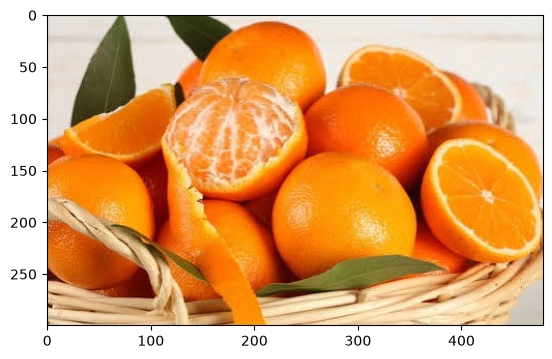

In [22]:
plt.imshow(imges_rgb)

# 3.matrix[ i, j, n] --> matrix[ 1, i*j, n]: Vector hóa dữ liệu / Duỗi mảng thành dạng vectorh

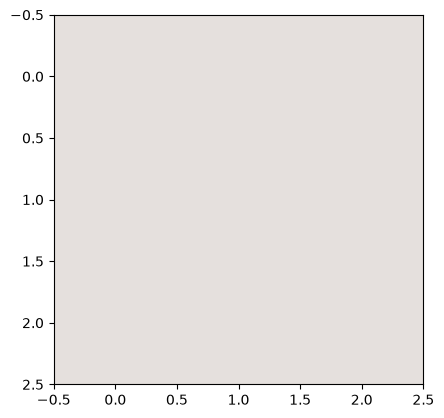

In [23]:
plt.imshow(imges_rgb[:3,:3,:])

In [24]:
print(imges_rgb)

[[[229 224 221]
  [229 224 221]
  [229 224 221]
  ...
  [237 236 232]
  [237 236 232]
  [236 235 231]]

 [[229 224 221]
  [229 224 221]
  [229 224 221]
  ...
  [237 236 232]
  [236 235 231]
  [236 235 231]]

 [[229 224 221]
  [229 224 221]
  [229 224 221]
  ...
  [236 235 231]
  [236 235 231]
  [236 235 231]]

 ...

 [[ 74  37   0]
  [ 98  61  17]
  [147 112  70]
  ...
  [204 196 185]
  [204 196 185]
  [204 196 185]]

 [[143 106  62]
  [143 106  62]
  [170 135  93]
  ...
  [204 196 185]
  [204 196 185]
  [204 196 185]]

 [[157 120  76]
  [188 151 107]
  [216 181 139]
  ...
  [204 196 185]
  [204 196 185]
  [204 196 185]]]


In [25]:
imges_rgb.shape

(300, 479, 3)

In [26]:
img_vector = imges_rgb.reshape(1,-1,3)
img_vector.shape

(1, 143700, 3)

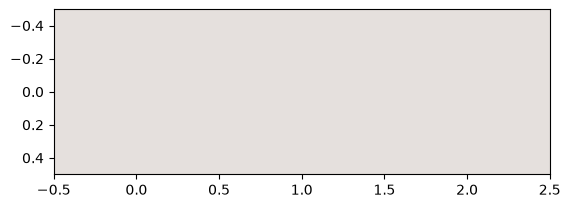

In [27]:
plt.imshow(img_vector[:,:3,:])

# 4.Tach thanh 3 mau( Red, Green, Blue)

In [28]:
Red = img_vector[0,:,0]
Green = img_vector[0,:,1]
Blue = img_vector[0,:,2]
Red.shape, Green.shape, Blue.shape

((143700,), (143700,), (143700,))

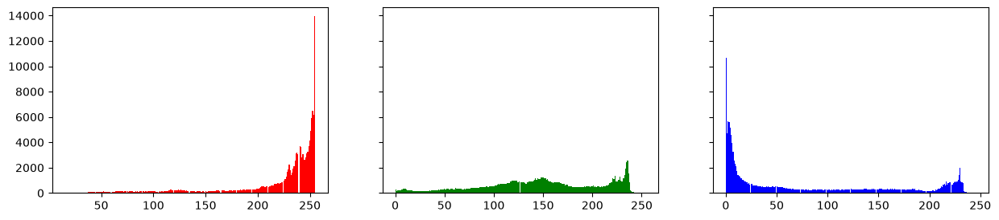

In [29]:
fig ,axs = plt.subplots(1,3,figsize=(15,3), sharey=True)
axs[0].hist(Red, bins=256, color = 'r')
axs[1].hist(Green, bins=256, color = 'g')
axs[2].hist(Blue, bins=256, color = 'b')
plt.show()

# 6. Gom tat ca (2,3,4,5) vao 1 ham

In [30]:
def build_histogram(image,bins = 256):
    # Chuyen bgr --> rgb
    rgb_image = np.flip(image, 2) 
    plt.imshow(rgb_image)

    # Vector hóa dữ liệu / Duỗi mảng thành dạng vector
    image_vector = rgb_image.reshape(1,-1,3) 

    # Phân khoảng / Gom thành số lượng nhóm (bins) được chỉ định
    div = 256/bins
    bins_vector =(image_vector/div).astype(int)

    # Trích xuất / Lấy các kênh màu đỏ (Red), xanh lá (Green) và xanh dương (Blue).
    Red = bins_vector[0,:,0]
    Green = bins_vector[0,:,1]
    Blue = bins_vector[0,:,2]

    fig, axs = plt.subplots(1,3,figsize = (10,3), sharey = True)
    axs[0].hist(Red, bins, color='r')
    axs[1].hist(Green, bins, color='g')
    axs[2].hist(Blue, bins, color='b')
    plt.show()
    

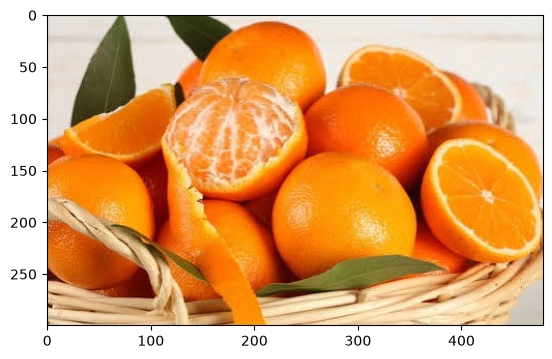

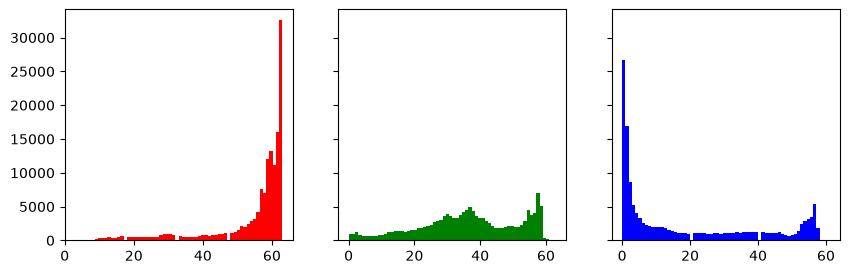

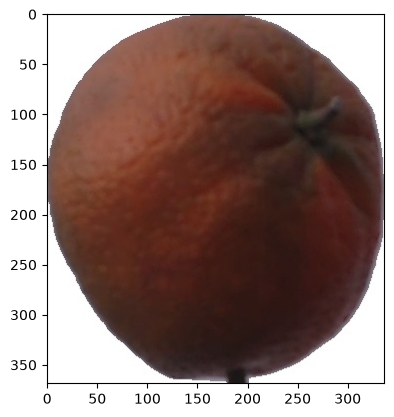

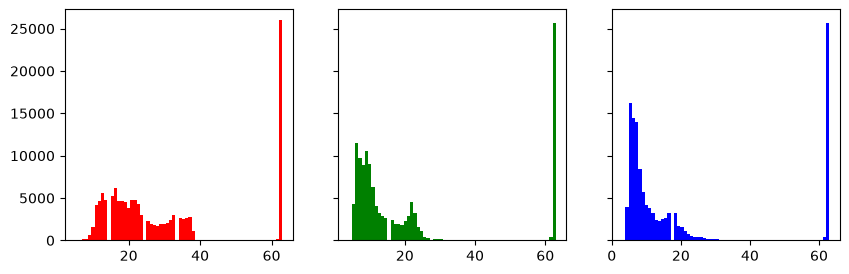

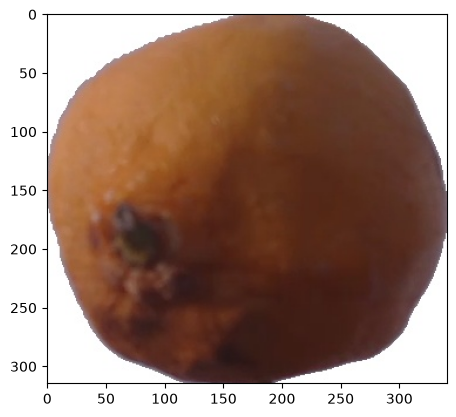

...

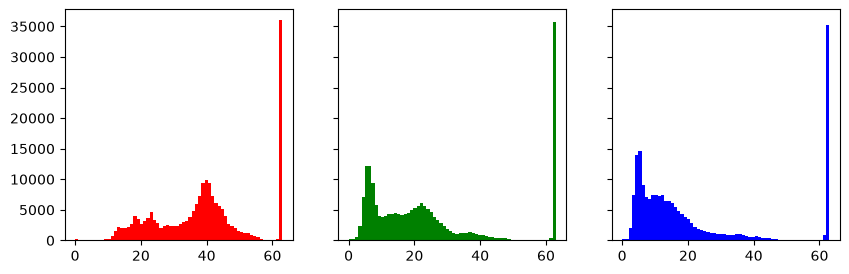

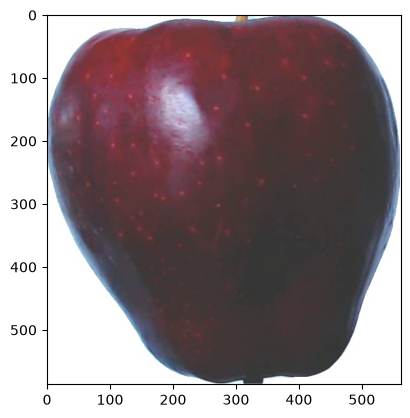

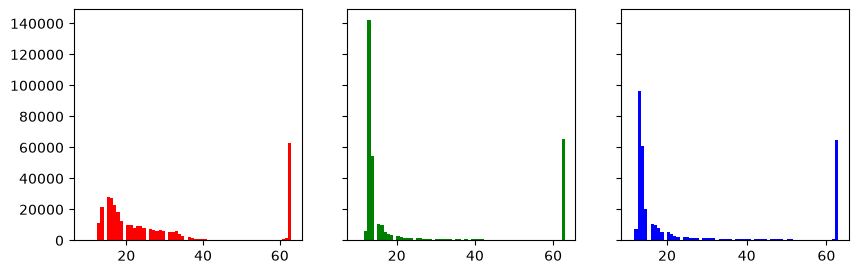

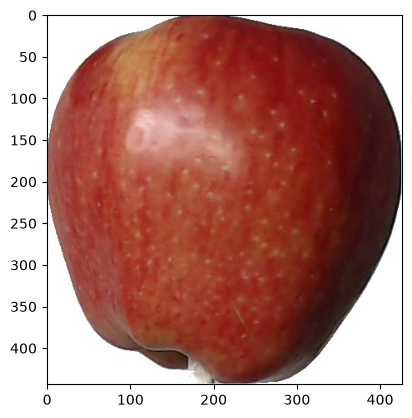

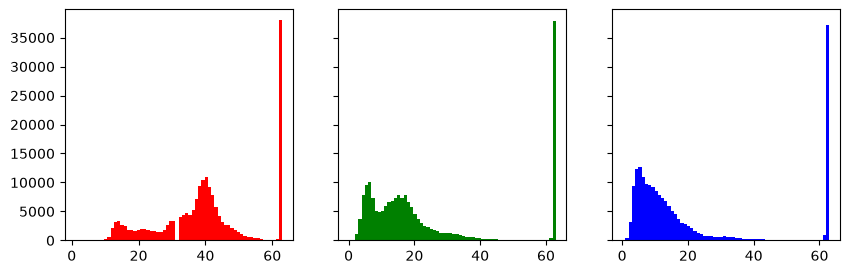

In [34]:
for i in range(len(imges)):
    build_histogram(imges[i], 64)

In [51]:
red_hist = cv2.calcHist(
    [imges[0]], [2], None, [64], [0, 256]
)
green_hist = cv2.calcHist(
    [imges[0]], [1], None, [64], [0, 256]
)
blue_hist = cv2.calcHist(
    [imges[0]], [0], None, [64], [0, 256]
)

red_hist.shape

(64,)

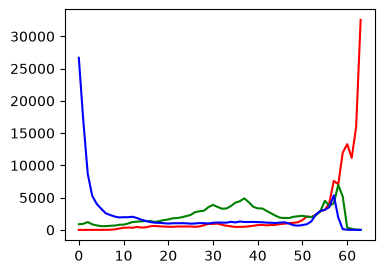

In [57]:
fig, ax = plt.subplots(figsize=(4, 3), sharey=True)
ax.plot(red_hist, color='r')
ax.plot(green_hist, color='g')
ax.plot(blue_hist, color='b')
plt.show()

In [53]:
def get_vector(image, bins=32):
    red = cv2.calcHist(
        [image], [2], None, [bins], [0, 256]
    )
    green = cv2.calcHist(
        [image], [1], None, [bins], [0, 256]
    )
    blue = cv2.calcHist(
        [image], [0], None, [bins], [0, 256]
    )
    vector = np.concatenate([red, green, blue], axis=0)
    vector = vector.reshape(-1)
    return vector

In [54]:
vec = get_vector(imges[0])
vec.shape

(96,)

In [39]:
# and do the same for the remainder of our images
image_vectors = []
for image in imges:
    image_vectors.append(get_vector(image))

In [47]:
def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [48]:

# during visualization we use this array of RGB images
rgb_images = [np.flip(image, 2) for image in imges]

def search(idx, top_k=5):
    query_vector = image_vectors[idx]
    distances = []
    for _, vector in enumerate(image_vectors):
        distances.append(cosine(query_vector, vector))
    # get top k most similar images
    top_idx = np.argpartition(distances, -top_k)[-top_k:]
    return top_idx

In [49]:
search(0)

array([10,  8,  9,  7,  0])